### <h3 style="color: #ADD8E6;">Complementaria 3: Cadenas de Markov en Python II</h3>

<h3 style="color: #ADD8E6;">Ejercicio de un hospital en tiempo continuo</h3>

Considere un hospital con $B = 20$ camas. Hay dos tipos de pacientes que usan este hospital. Los pacientes de tipo $i\ (i=1,2)$ llegan según un proceso de Poisson con tasa $\lambda_1 = 4$ y $\lambda_2 = 3$ pacientes por hora y requieren un servicio independiente e idénticamente distribuido (iid) con tiempos de servicio que siguen una distribución exponencial con parámetros $\mu_1 = 2$ y $\mu_2 = 1.5$ pacientes por hora. El hospital utiliza la siguiente política: reserva $b = 5$ camas para pacientes de tipo 1. Así, cuando un paciente de tipo 1 llega, se le admite en el hospital siempre que haya una cama disponible. Sin embargo, un paciente de tipo 2 es admitido solo si el número de pacientes de tipo 2 que actualmente ocupan camas es menor que $B-b$.

Se le ha solicitado modelar la anterior situación definiendo claramente variables de estado, espacios de estado y matriz de transición o generadora según sea el caso.


### Preguntas:
1. Construya la matriz de tasas de transición $\mathbb{Q}$, luego cree la cadena de Markov utilizando la librería `jmarkov`.
2. Calcule la probabilidad de que después de 6 horas el hospital tenga 10 pacientes tipo 1 y 5 pacientes tipo 2, dado que al inicio está vacío.
3. ¿Cuál es la probabilidad de que hayan 4 pacientes tipo 2 luego de 5 horas? Asuma que al inicio había un paciente de tipo 1 y un paciente de tipo 2.
4. Calcule la varianza del número total de pacientes en el hospital tras 1 hora y tras 6 horas, dado que al inicio está vacío. Compare los resultados obtenidos.
5. Genere una gráfica de la probabilidad de que haya más pacientes tipo 1 que tipo 2 en función del tiempo, desde 0 hasta 24 horas.


<h4 style="color: #ADD8E6;">Parte A. Modelar el sistema del hospital como una cadena de Markov</h4>

**Variables de estado:**
- $X\left(t\right)$: El número de pacientes tipo 1 en el tiempo $t$.
- $Y\left(t\right)$: El número de pacientes tipo 2 en el tiempo $t$.
- $Z\left(t\right)$: $\{X\left(t\right),\ Y\left(t\right)\}$.

**Espacio de estados:**

$$
S_X=\{0,\ 1,\ 2,\ 3,\ \ldots,B\}
$$

$$
S_Y=\{0,\ 1,\ 2,\ 3,\ \ldots,B-b\}
$$

$$
S_Z=\{(i,j):0\le i\le B,\ 0\le j\le B-b\}
$$

**Matriz generadora:**

$$
Q((i,j),(i',j')) = \begin{cases}
\lambda_1, & \text{si } i' = i + 1,\; j' = j,\; i < B, \\[1mm]
\lambda_2, & \text{si } j' = j + 1,\; i' = i,\; j < B - b, \\[1mm]
i \cdot \mu_1, & \text{si } i' = i - 1,\; j' = j,\; i > 0, \\[1mm]
j \cdot \mu_2, & \text{si } j' = j - 1,\; i' = i,\; j > 0, \\[1mm]
0, & \text{en otro caso (d.l.c.)}.
\end{cases}
$$

A continuación, se implementa el modelo en Python.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from jmarkov.ctmc import ctmc

# Definimos los parámetros
B = 20  # Número total de camas
b = 5   # Número de camas reservadas para pacientes tipo 1
lambda_1 = 4  # Tasa de llegada de pacientes tipo 1 (por hora)
lambda_2 = 3  # Tasa de llegada de pacientes tipo 2 (por hora)
mu_1 = 2      # Tasa de salida de pacientes tipo 1 (por hora)
mu_2 = 1.5    # Tasa de salida de pacientes tipo 2 (por hora)

# Dimensión de la matriz Q
num_estados = (B + 1) * (B - b + 1)

# Inicializamos la matriz Q con ceros
Q_evaluar = np.zeros((num_estados, num_estados), dtype=float)

# Función para mapear (i, j) a índice en la matriz Q
def index(i, j):
    return i * (B - b + 1) + j

# Llenar la matriz Q
for i in range(B + 1):
    for j in range(B - b + 1):
        idx = index(i, j)

        # Llegada de un paciente tipo 1
        if i < B:
            Q_evaluar[idx, index(i + 1, j)] = lambda_1

        # Llegada de un paciente tipo 2 (si hay espacio disponible)
        if j < B - b:
            Q_evaluar[idx, index(i, j + 1)] = lambda_2

        # Salida de un paciente tipo 1
        if i > 0:
            Q_evaluar[idx, index(i - 1, j)] = i * mu_1

        # Salida de un paciente tipo 2
        if j > 0:
            Q_evaluar[idx, index(i, j - 1)] = j * mu_2

# Llenar la diagonal con la suma negativa de las filas de la matriz
for i in range(num_estados):
    Q_evaluar[i, i] = -np.sum(Q_evaluar[i, :])
    
print(Q_evaluar)

[[ -7.    3.    0.  ...   0.    0.    0. ]
 [  1.5  -8.5   3.  ...   0.    0.    0. ]
 [  0.    3.  -10.  ...   0.    0.    0. ]
 ...
 [  0.    0.    0.  ... -62.5   3.    0. ]
 [  0.    0.    0.  ...  21.  -64.    3. ]
 [  0.    0.    0.  ...   0.   22.5 -62.5]]


Para crear la cadena de markov utilizaremos la instancia `dtmc` la libreria `jmarkov`, ya que estamos creando una cadena de tiempo discreto.

In [3]:
from jmarkov.ctmc import ctmc

# Crear la cadena de Markov en tiempo continuo usando jmarkov
hospital_chain = ctmc(Q_evaluar)

<h4 style="color: #ADD8E6;">Parte B. Responder preguntas de interés</h4>

<h5 style="color: #ADD8E6;">2. Cálculo de la probabilidad de que, después de 6 horas, el hospital tenga 10 pacientes tipo 1 y 5 pacientes tipo 2</h5>

Para resolver a esta pregunta primero se debe establecer correctamente el vector de estado inicial (hospital vacío).

In [4]:
# --------------------------------------------------------------------
# Pregunta 2: Probabilidad de que después de 6 horas el hospital tenga 10 pacientes tipo 1, y 5
# pacientes tipo 2, dado que al inicio está vacío.
alpha = np.zeros(num_estados)
alpha[index(0, 0)] = 1

Una vez definido este vector, se puede calcular la distribución de probabilidad a las 6 horas utilizando la función `transient_probabilities` de `jmarkov`

In [5]:
# Probabilidades transitorias en 6 horas
probs_transitorias_6h = hospital_chain.transient_probabilities(t=6, alpha=alpha)

Con esto podemos identificar que la probabilidad correspondiente al estado $(10,5)$ es la siguiente:

In [6]:
# Probabilidad de que el estado sea (10,5)
prob_10_5 = probs_transitorias_6h[index(10, 5)]
print(f"Probabilidad de que después de 6 horas haya 10 pacientes tipo 1 y 5 tipo 2: {prob_10_5:.6f}")

Probabilidad de que después de 6 horas haya 10 pacientes tipo 1 y 5 tipo 2: 0.000001


<h5 style="color: #ADD8E6;">3. Cálculo de la probabilidad de que hayan 4 pacientes tipo 2 luego de 5 horas</h5>

Para este caso debemos establecer el vector de estado inicial con 1 paciente de tipo 1 y 1 paciente de tipo 2.

In [7]:
# --------------------------------------------------------------------
# Pregunta 3: ¿Cuál es la probabilidad de que hayan 4 pacientes tipo 2 luego de 5 horas?
# Partiendo de que el hospital tenía 1 paciente tipo 1 y 1 paciente tipo 2.
alpha = np.zeros(num_estados)
alpha[index(1,1)] = 1

Calculamos la distribución del sistema a las 5 horas.

In [8]:
probs_transitorias_5h = hospital_chain.transient_probabilities(t=5, alpha=alpha)

Para responder a la pregunta debemos sumar las probabilidades de los estados en los que hay 4 pacientes tipo 2.

In [9]:
# Sumamos las probabilidades de todos los estados en los que j == 4 (independientemente de i)
prob_4_tipo2 = sum(probs_transitorias_5h[index(i, 4)] for i in range(B + 1))
print(f"Probabilidad de que hayan 4 pacientes tipo 2 luego de 5 horas: {prob_4_tipo2:.6f}")

Probabilidad de que hayan 4 pacientes tipo 2 luego de 5 horas: 0.090174


<h5 style="color: #ADD8E6;">4. Cálculo de la varianza del número total de pacientes tras 1 hora y 6 horas</h5>

Para calcular la varianza podemos utilizar la fórmula de momentos $E[(\text{Total de pacientes})]$ y $E[(\text{Total de pacientes})^2]$ a la 1 y 6 horas.

La varianza se define como:
        $$
        \operatorname{Var}(\text{Pacientes}) = E[(\text{Pacientes})^2] - \Bigl(E[\text{Pacientes}]\Bigr)^2,
        $$

        
Dado que ya habíamos definido el vector de probabilidades para 6 horas en el punto 2, solo es necesario que definamos el vector tras 1 hora:

In [10]:
# Probabilidades transitorias en 1 hora
alpha = np.zeros(num_estados)
alpha[index(0, 0)] = 1
probs_transitorias_1h = hospital_chain.transient_probabilities(t=1, alpha=alpha)

Para la siguiente parte podemos definir una función que calcule la varianza en términos del valor esperado.

In [11]:
# Función para calcular varianza dada una distribución de probabilidad
def calcular_varianza(probs):
    esperanza = sum((i + j) * probs[index(i, j)]
                    for i in range(B + 1)
                    for j in range(B - b + 1))
    
    esperanza_cuadrado = sum(probs[index(i, j)] * (i + j) ** 2
                             for i in range(B + 1)
                             for j in range(B - b + 1))
    varianza = esperanza_cuadrado - esperanza ** 2
    return varianza

Ahora respondemos a la pregunta llamando esa función y utilizando como parámetro los dos vectores de probabilidades pasadas 1 hora y 6 horas:

In [12]:
# Cálculo de varianza en los distintos momentos
varianza_1h = calcular_varianza(probs_transitorias_1h)
varianza_6h = calcular_varianza(probs_transitorias_6h)

# Mostrar resultados
print(f"Varianza del número de pacientes tras 1 hora: {varianza_1h:.3f}")
print(f"Varianza del número de pacientes tras 6 horas: {varianza_6h:.3f}")

Varianza del número de pacientes tras 1 hora: 3.283
Varianza del número de pacientes tras 6 horas: 4.000


<h5 style="color: #ADD8E6;">5. Generación de la gráfica de la probabilidad de que haya más pacientes tipo 1 que tipo 2 en función del tiempo (0 a 24 horas)</h5>

Para este punto calculamos inicialmente la probabilidad para cada punto de tiempo en el intervalo de 0 a 24 horas. Esto lo guardamos en un vector que graficamos de la sigueinte forma utilizando `matplotlib`:

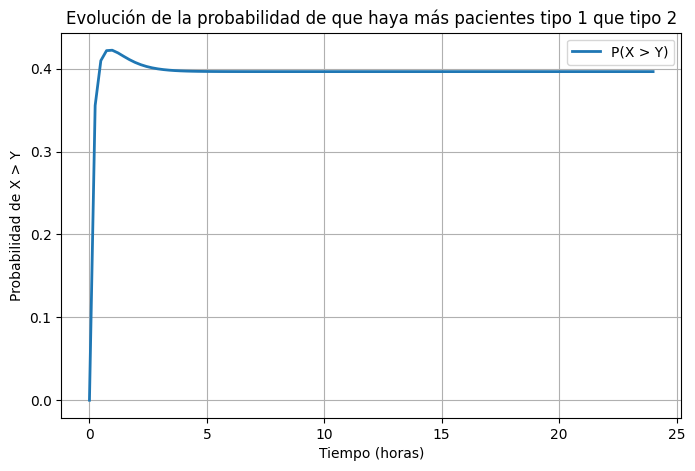

In [13]:
# --------------------------------------------------------------------
### Pregunta 5: Evolución de la probabilidad de que haya más pacientes tipo 1 que tipo 2
# Definir tiempos de evaluación
puntos_de_tiempo = np.linspace(0, 24, 100)

# Calcular la distribución transitoria para cada punto en el tiempo
probabilidad_mas_tipo_1 = []

for t in puntos_de_tiempo:
    probs_transitorias_t = hospital_chain.transient_probabilities(t=t, alpha=alpha)
    prob_mas_1 = sum(probs_transitorias_t[index(i, j)]
                     for i in range(B + 1)
                     for j in range(B - b + 1)
                     if i > j)
    probabilidad_mas_tipo_1.append(prob_mas_1)

# Graficar la evolución de la probabilidad de que haya más pacientes tipo 1 que tipo 2
plt.figure(figsize=(8, 5))
plt.plot(puntos_de_tiempo, probabilidad_mas_tipo_1, label="P(X > Y)", linewidth=2)
plt.xlabel("Tiempo (horas)")
plt.ylabel("Probabilidad de X > Y")
plt.title("Evolución de la probabilidad de que haya más pacientes tipo 1 que tipo 2")
plt.legend()
plt.grid(True)
plt.show()

<h5 style="color: #ADD8E6;">Cálculo teórico del estado estable para la condición $X > Y$</h5>

Para calcular el valor teórico a largo plazo (estado estable) de que haya más pacientes tipo 1 que tipo 2, primero definimos $\pi_{(i,j)}$ como la probabilidad límite de que el sistema se encuentre en el estado con $i$ pacientes de tipo 1 y $j$ pacientes de tipo 2.

Estas probabilidades se obtienen al resolver el sistema de ecuaciones de balance global de la cadena:

$$
\pi \mathbb{Q} = 0
$$

Sujeto a la restricción de normalización, donde la suma de todas las probabilidades debe ser igual a 1:

$$
\sum_{i=0}^{B} \sum_{j=0}^{B-b} \pi_{(i,j)} = 1
$$

Una vez hallado el vector de probabilidades en estado estable $\pi$, la probabilidad de que haya estrictamente más pacientes tipo 1 que tipo 2 en el largo plazo se define como la suma de las probabilidades de todos los estados $(i,j)$ que cumplen la condición $i > j$:

$$
\lim_{t \to \infty} P(X(t) > Y(t)) = \sum_{(i,j) \in S, i > j} \pi_{(i,j)}
$$

Lo cual, desarrollando los límites de las sumatorias para nuestro espacio de estados, equivale a:

$$
P(X > Y) = \sum_{i=1}^{B} \sum_{j=0}^{\min(i-1, B-b)} \pi_{(i,j)}
$$

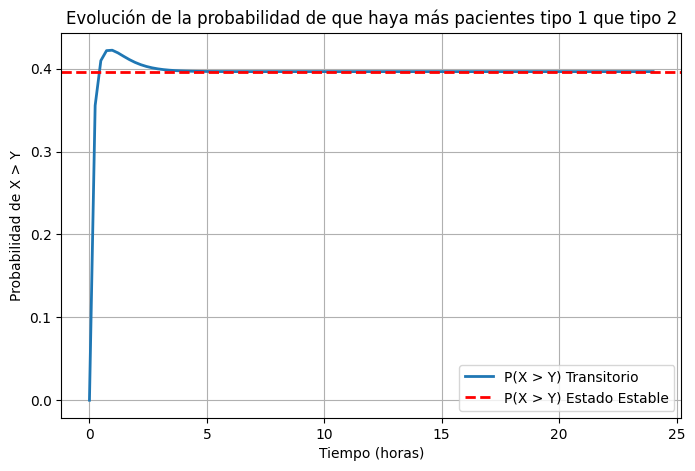

In [14]:
# --------------------------------------------------------------------
### Pregunta 5: Evolución de la probabilidad de que haya más pacientes tipo 1 que tipo 2
# Definir tiempos de evaluación
puntos_de_tiempo = np.linspace(0, 24, 100)

# Calcular la distribución transitoria para cada punto en el tiempo
probabilidad_mas_tipo_1 = []

for t in puntos_de_tiempo:
    probs_transitorias_t = hospital_chain.transient_probabilities(t=t, alpha=alpha)
    prob_mas_1 = sum(probs_transitorias_t[index(i, j)]
                     for i in range(B + 1)
                     for j in range(B - b + 1)
                     if i > j)
    probabilidad_mas_tipo_1.append(prob_mas_1)

# ----------------- NUEVO: Cálculo del Estado Estable -----------------
# Calcular la distribución en estado estable
pi_estable = hospital_chain.steady_state()

# Sumar las probabilidades donde i > j en estado estable
prob_mas_1_estable = sum(pi_estable[index(i, j)]
                         for i in range(B + 1)
                         for j in range(B - b + 1)
                         if i > j)
# ---------------------------------------------------------------------

# Graficar la evolución de la probabilidad de que haya más pacientes tipo 1 que tipo 2
plt.figure(figsize=(8, 5))
plt.plot(puntos_de_tiempo, probabilidad_mas_tipo_1, label="P(X > Y) Transitorio", linewidth=2)

# Añadir la línea horizontal roja para el estado estable
plt.axhline(y=prob_mas_1_estable, color='r', linestyle='--', label="P(X > Y) Estado Estable", linewidth=2)

plt.xlabel("Tiempo (horas)")
plt.ylabel("Probabilidad de X > Y")
plt.title("Evolución de la probabilidad de que haya más pacientes tipo 1 que tipo 2")
plt.legend()
plt.grid(True)
plt.show()

<h4 style="color: #ADD8E6;">Parte C. Análisis a largo plazo y tiempos de transición</h4>

A partir de la cadena de Markov construida, utilice las funciones integradas de la librería para resolver las siguientes preguntas:

6. **Estado Estable y Costos:** Calcule la distribución de probabilidad en estado estable. Si cada paciente tipo 1 genera un costo operativo por insumos de 100 pesos por hora y cada paciente tipo 2 un costo de 80 pesos por hora, ¿cuál es el costo operativo total esperado por hora en el largo plazo?
7. **Tiempo de Primera Pasada:** Si actualmente el hospital se encuentra completamente vacío, ¿cuánto tiempo pasará en promedio para que se alcance por primera vez un estado con 10 pacientes tipo 1 y 5 pacientes tipo 2?
8. **Tiempo de Ocupación:** Si se observa la cadena durante un día completo (24 horas), ¿cuánto tiempo durará el hospital completamente vacío dado que actualmente hay 1 paciente de tipo 1 y 1 paciente de tipo 2?

<h5 style="color: #ADD8E6;">6. Cálculo del costo operativo esperado en estado estable</h5>

Para encontrar el comportamiento a largo plazo, calculamos la distribución límite utilizando el método `.steady_state()`. Posteriormente, multiplicamos este vector de probabilidades por un vector con los costos asociados a cada estado y sumamos los valores para hallar el valor esperado.

In [15]:
# --------------------------------------------------------------------
# Pregunta 6: Costo esperado a largo plazo usando estado estable

# Obtener vector de probabilidades en estado estable
probs_estable = hospital_chain.steady_state()

# Construir el vector de costos para cada estado (i pacientes tipo 1, j pacientes tipo 2)
costos_estados = np.zeros(num_estados)
for i in range(B + 1):
    for j in range(B - b + 1):
        costos_estados[index(i, j)] = (100 * i) + (80 * j)

# El costo esperado es la suma del producto de las probabilidades límite y los costos
costo_esperado_largo_plazo = sum(probs_estable * costos_estados)

print(f"Costo operativo total esperado por hora: ${costo_esperado_largo_plazo:.2f}")

Costo operativo total esperado por hora: $360.00


<h5 style="color: #ADD8E6;">7. Tiempo esperado de primera pasada al estado (10, 5)</h5>

Utilizamos el método `.first_passage_time()` de la cadena para obtener la matriz de tiempos promedios de primera visita y extraemos el valor correspondiente al viaje desde el estado $(0,0)$ hasta el estado $(10,5)$.

In [16]:
# --------------------------------------------------------------------
# Pregunta 7: Tiempo esperado de primera pasada

idx_vacio = index(0, 0)
idx_objetivo = index(10, 5)

# La función first_passage_time recibe el estado objetivo (target) como argumento.
# Retorna un arreglo con los tiempos desde cada posible estado inicial.
# Evaluamos en la posición del estado inicial (idx_vacio).
tiempo_0_a_10_5 = hospital_chain.first_passage_time(idx_objetivo)[idx_vacio]



print(f"Tiempo esperado hasta tener 10 pacientes tipo 1 y 5 tipo 2: {tiempo_0_a_10_5[0]:.4f} horas")

Tiempo esperado hasta tener 10 pacientes tipo 1 y 5 tipo 2: 27770.0781 horas


<h5 style="color: #ADD8E6;">8. Tiempo de ocupación en estado vacío durante 24 horas</h5>

Aplicamos el método `.occupation_time(t)` para un periodo de $t=24$ horas. Esta función nos devuelve una matriz donde podemos ubicar el tiempo esperado que la cadena pasa en el estado $(0,0)$ si partimos del estado $(1,1)$.

In [17]:
# --------------------------------------------------------------------
# Pregunta 8: Tiempo de ocupación

idx_vacio = index(0, 0)
idx_inicial = index(1, 1)

# Generar la matriz de tiempos de ocupación para 24 horas
matriz_ocupacion = hospital_chain.occupation_time(24)

# Extraer el tiempo en el estado objetivo (idx_vacio) asumiendo que arranca en el inicial (idx_inicial)
# Se utiliza la indexación [fila, columna]
tiempo_vacio_24h = matriz_ocupacion[idx_inicial, idx_vacio]

print(f"Tiempo esperado que el hospital estará vacío durante 24 horas: {tiempo_vacio_24h:.4f} horas")

Tiempo esperado que el hospital estará vacío durante 24 horas: 0.4520 horas


Universidad de los Andes | Vigilada Mineducación. Reconocimiento como Universidad: Decreto 1297 del 30 de mayo de 1964. Reconocimiento personería jurídica: Resolución 28 del 23 de febrero de 1949 Minjusticia. Departamento de Ingeniería Industrial Carrera 1 Este No. 19 A 40 Bogotá, Colombia Tel. (57.1) 3324320 | (57.1) 3394949 Ext. 2880 /2881 http://industrial.uniandes.edu.co